# Experiment 4: Fraud Detection using Logistic Regression (Without SMOTE)

### Aim:
To build a Logistic Regression model for fraud detection and evaluate its performance on an imbalanced dataset without applying any resampling technique.

### Objective:
To observe the effect of class imbalance on model performance and identify limitations before applying SMOTE in the next experiment.

### Theory:
Fraud detection is a binary classification problem where fraudulent transactions are significantly fewer than legitimate ones. When training models on imbalanced datasets without corrective techniques, models tend to favor the majority class.

Logistic Regression is a linear classification algorithm that estimates probability using the sigmoid function.

In imbalanced datasets, accuracy alone is misleading. Therefore, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC are used.


In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve


In [15]:
df = pd.read_csv("data/online_fraud.csv")

# Sample for faster processing
df = df.sample(n=100000, random_state=42)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (100000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
3737323,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
264914,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
85647,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
5899326,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
2544263,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


In [16]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)


In [17]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)


In [18]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [21]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [23]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


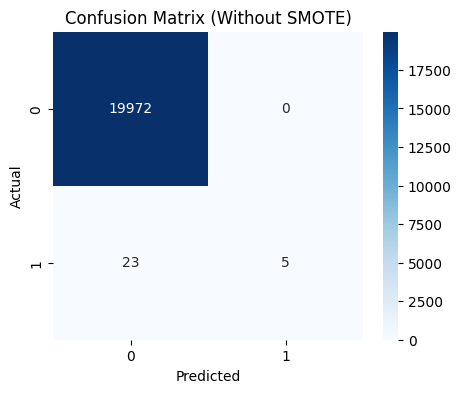

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Without SMOTE)")
plt.show()


In [25]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19972
           1       1.00      0.18      0.30        28

    accuracy                           1.00     20000
   macro avg       1.00      0.59      0.65     20000
weighted avg       1.00      1.00      1.00     20000



Very high Accuracy (~99%)

Very low Recall for fraud

Many False Negatives

Poor F1-score for fraud class

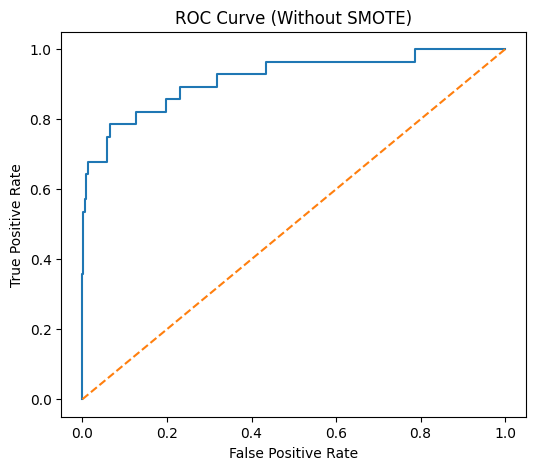

ROC-AUC Score: 0.9172251866899372


In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Without SMOTE)")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


## Conclusion:

The Logistic Regression model was trained on an imbalanced dataset without applying any resampling technique.

Although the model achieved high overall accuracy, it performed poorly in detecting fraudulent transactions. The recall for fraud class was low, indicating that many fraudulent cases were misclassified as legitimate transactions.

This demonstrates the negative impact of class imbalance on model performance.

In the next experiment, SMOTE will be applied to address class imbalance and improve fraud detection performance.
